# package_DBR

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

import package_DBR
from package_DBR import myRound, SelectPath_RT, Delay_RT, FO_RT, FOPDT, SOPDT, FOPDT_cost, SOPDT_cost, Process, Bode
import package_LAB
from package_LAB import LL_RT, PID_RT

# LL_RT()

In [110]:
help(LL_RT)

Help on function LL_RT in module package_LAB:

LL_RT(MV, Kp, Tlag, Tlead, Ts, PV, PVInit=0, method='EBD')
    The function "FO_RT" needs to be included in a "for or while loop".

    :MV: input vector
    :Kp: process gain
    :Tlag: lag time constant [s]
    :Tlead: lag time constant [s]
    :Ts: sampling period [s]
    :PV: output vector
    :PVInit: (optional: default value is 0)
    :method: discretisation method (optional: default value is 'EBD')
        EBD: Euler Backward difference
        EFD: Euler Forward difference
        TRAP: Trapezoïdal method

    The function "FO_RT" appends a value to the output vector "PV".
    The appended value is obtained from a recurrent equation that depends on the discretisation method.



(0.0, 100.0)

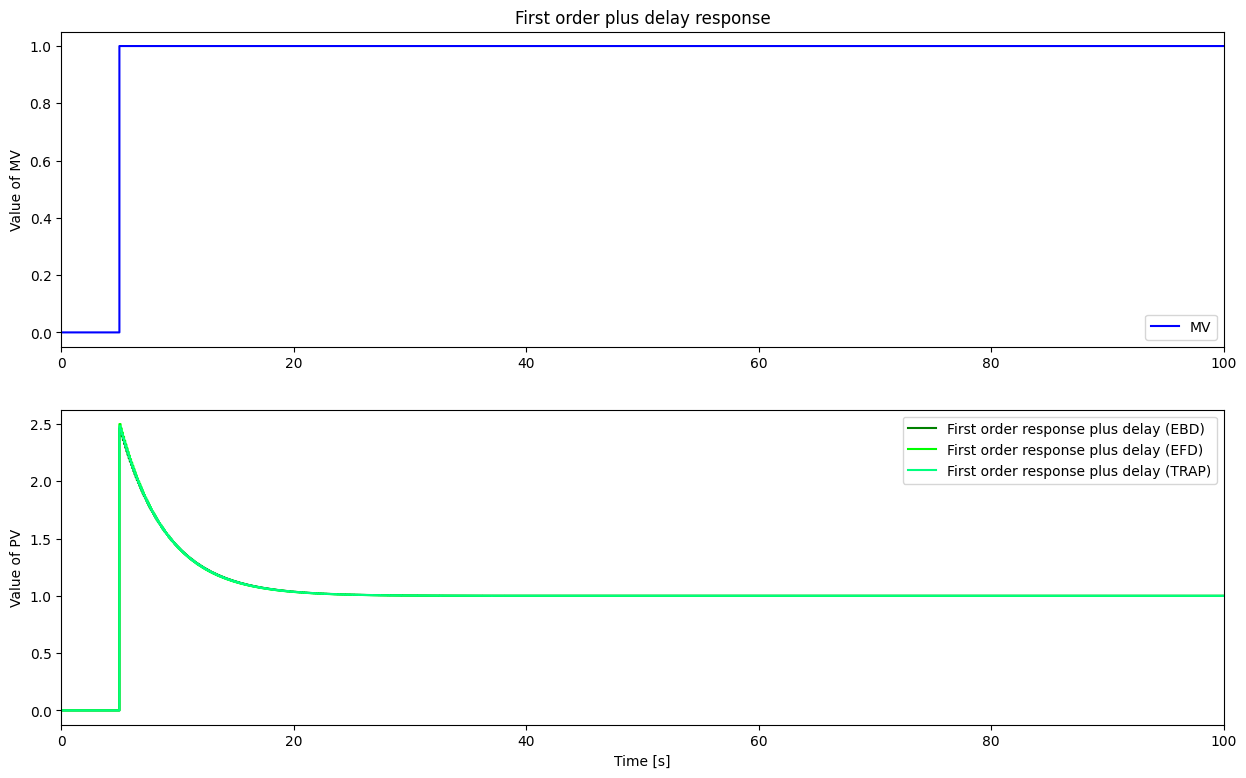

In [111]:
TSim = 100
Ts = 0.1
N = int(TSim/Ts) + 1

# Path for MV
MVPath = {0: 0, 5: 1, TSim: 1}

t = []
MV = []
PV_EBD = []
PV_EFD = []
PV_TRAP = []

# Parameters
Kp = 1
Tlag = 4
Tlead = 10
theta = 10

for i in range(0,N):
    t.append(i*Ts)
    SelectPath_RT(MVPath,t,MV)
    LL_RT(MV,Kp,Tlag,Tlead,Ts,PV_EBD)
    LL_RT(MV,Kp,Tlag,Tlead,Ts,PV_EFD,0,'EFD')
    LL_RT(MV,Kp,Tlag,Tlead,Ts,PV_TRAP,0,'TRAP')
    
plt.figure(figsize = (15,9))

plt.subplot(2,1,1)
plt.step(t,MV,'b-',label='MV',where='post')
plt.ylabel('Value of MV')
plt.title('First order plus delay response')
plt.legend(loc='best')
plt.xlim([0, TSim])

plt.subplot(2,1,2)
plt.step(t,PV_EBD,'g-',label='First order response plus delay (EBD)',where='post')
plt.step(t,PV_EFD,'lime',label='First order response plus delay (EFD)',where='post')
plt.step(t,PV_TRAP,'springgreen',label='First order response plus delay (TRAP)',where='post')
plt.ylabel('Value of PV')
plt.xlabel('Time [s]')
plt.legend(loc='best')
plt.xlim([0, TSim])    

# PID_RT()

In [112]:
help(PID_RT)

Help on function PID_RT in module package_LAB:

PID_RT(
    SP,
    PV,
    Man,
    MVMan,
    MVFF,
    Kc,
    Ti,
    Td,
    alpha,
    Ts,
    MVMin,
    MVMax,
    MV,
    MVP,
    MVI,
    MVD,
    E,
    ManFF=False,
    PVInit=0,
    method='EBD-EBD'
)
    Real-time PID controller with feedforward, manual mode, and anti wind-up.

    Key design choice — anti wind-up excludes MVD:
        MVI_reset = MV_sat - MVP - MVFF   (MVD intentionally excluded)
    MVD is a transient term that decays on its own. Including it in the reset
    causes MVI to jump violently at SP steps, producing an unwanted MV bump.
    The final MV output is hard-clamped to [MVMin, MVMax] instead.



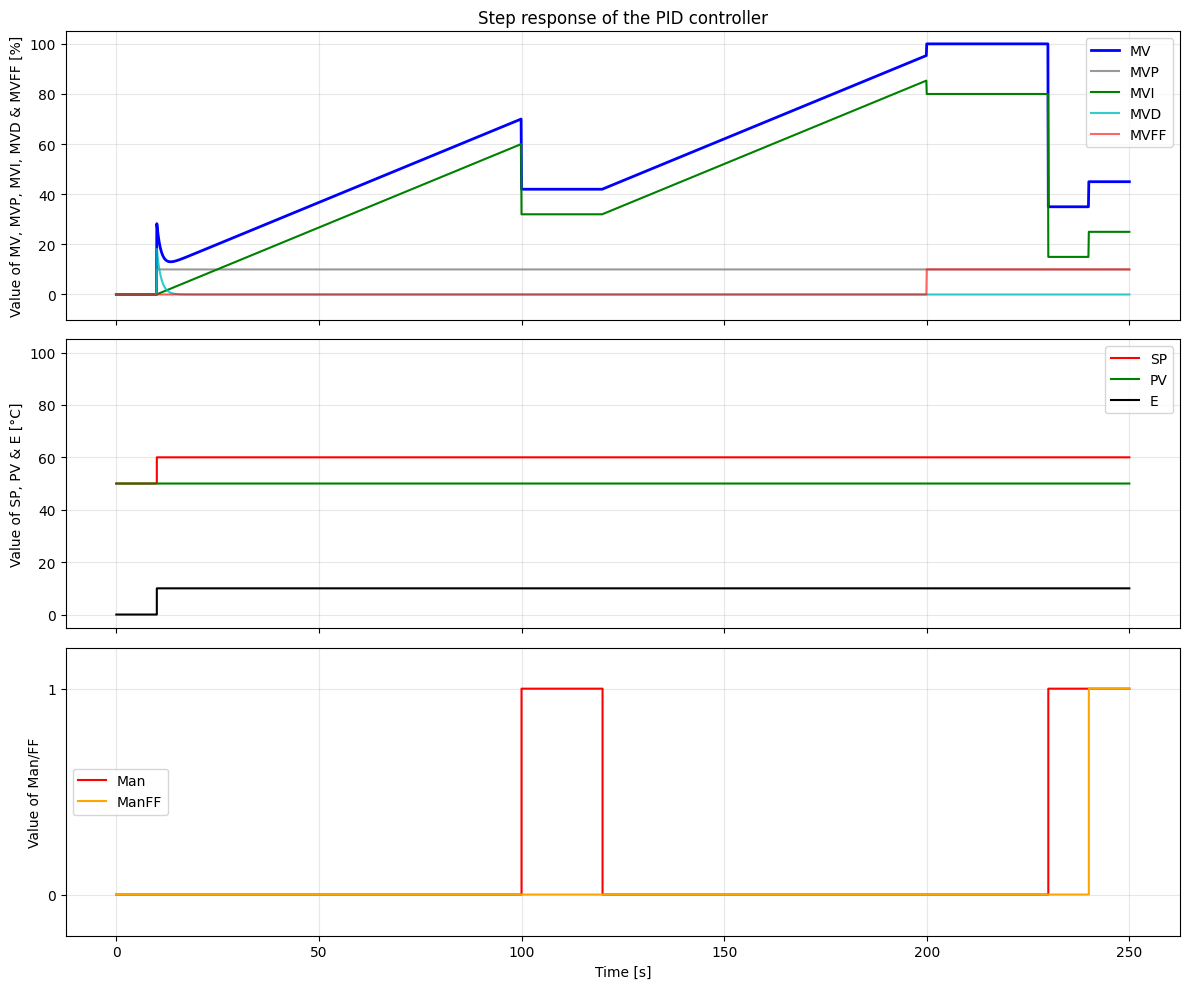

In [113]:
import matplotlib.pyplot as plt

# --- 1. Paramètres de Simulation (Test Boucle Ouverte du PID) ---
TSim = 250.0
Ts   = 0.1
N    = int(TSim / Ts) + 1

# Réglages PID (estimés d'après la pente de ton MVI et le pic du MVD)
Kc, Ti, Td, alpha = 1.0, 15.0, 2.0, 0.5
MVMin, MVMax = 0.0, 100.0

# --- 2. Initialisation des Vecteurs ---
t, SP, PV, E = [], [], [], []
MV, MVP, MVI, MVD, MVFF = [], [], [], [], []
Man, MVMan, ManFF = [], [], []

# --- 3. Boucle de Simulation ---
for i in range(N):
    curr_t = i * Ts
    t.append(curr_t)
    
    # PV reste constant à 50 (boucle ouverte, pas de modèle de procédé)
    pv_val = 50.0
    PV.append(pv_val)
    
    # Setpoint (SP) : Échelon de 50 à 60 à t=10s
    sp_val = 60.0 if curr_t >= 10 else 50.0
    SP.append(sp_val)
    
    # Mode Manuel (Man) : Actif de 100s à 120s, puis à nouveau après 230s
    is_man = True if (100 <= curr_t < 120) or (curr_t >= 230) else False
    Man.append(is_man)
    
    # Valeur forcé en Manuel (MVMan) : ~42% au premier créneau, ~35% au second
    mv_man_val = 42.0 if curr_t < 230 else 35.0
    MVMan.append(mv_man_val)
    
    # Feedforward (MVFF) : Échelon à 10% à partir de t=200s
    mv_ff_val = 10.0 if curr_t >= 200 else 0.0
    MVFF.append(mv_ff_val)
    
    # Mode Feedforward Manuel (ManFF) : Actif à partir de 240s
    is_man_ff = True if curr_t >= 240 else False
    ManFF.append(is_man_ff)

    # 4. APPEL DE TA FONCTION PID EN TEMPS RÉEL
    PID_RT(SP, [pv_val], Man, MVMan, [mv_ff_val], 
           Kc, Ti, Td, alpha, Ts, 
           MVMin, MVMax, 
           MV, MVP, MVI, MVD, E, 
           ManFF=is_man_ff, PVInit=50.0)

# --- 4. Affichage (Reproduction fidèle de ton image) ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Subplot 1 : Sorties du contrôleur (MV, MVP, MVI, MVD, MVFF)
ax1.plot(t, MV,   'b-',  label='MV', linewidth=2)
ax1.plot(t, MVP,  'gray',label='MVP', alpha=0.8)
ax1.plot(t, MVI,  'g-',  label='MVI', linewidth=1.5)
ax1.plot(t, MVD,  'c-',  label='MVD', alpha=0.8)
ax1.plot(t, MVFF, 'r-',  label='MVFF', alpha=0.6)
ax1.set_ylabel('Value of MV, MVP, MVI, MVD & MVFF [%]')
ax1.set_ylim([-10, 105])
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_title('Step response of the PID controller')

# Subplot 2 : Variables du procédé et Erreur (SP, PV, E)
ax2.step(t, SP, 'r-', label='SP', where='post', linewidth=1.5)
ax2.plot(t, PV, 'g-', label='PV', linewidth=1.5)
ax2.step(t, E,  'k-', label='E',  where='post', linewidth=1.5)
ax2.set_ylabel('Value of SP, PV & E [°C]')
ax2.set_ylim([-5, 105])
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# Subplot 3 : États booléens (Man et ManFF) allant de 0 à 1
ax3.step(t, Man,   'r-', label='Man',   where='post', linewidth=1.5)
ax3.step(t, ManFF, 'orange', label='ManFF', where='post', linewidth=1.5)
ax3.set_ylabel('Value of Man/FF')
ax3.set_xlabel('Time [s]')
ax3.set_ylim([-0.2, 1.2])
ax3.set_yticks([0, 1])
ax3.legend(loc='center left')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

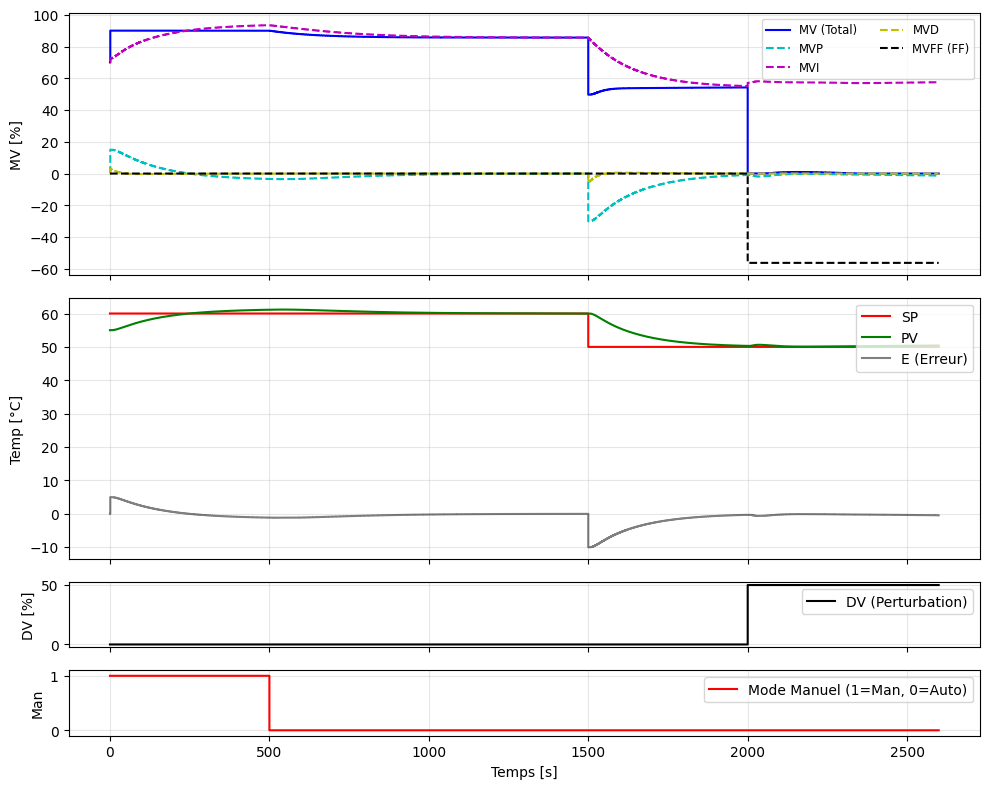

In [114]:
Ts = 1.0
Tsim = 2600
t = np.arange(0, Tsim, Ts)

# Modèles (issus de tes identifications)
K_p, T1_p, T2_p, theta_p = 0.32, 149.5, 15.0, 4.0   # Procédé (H1 -> T1)
K_d, T1_d, T2_d, theta_d = 0.36, 170.77, 6.12, 5.43  # Perturbation (H2 -> T1)

# Réglages PID
Kc, Ti, Td, alpha = 3.0, 150.0, 5.0, 5 # Alpha réduit à 0.1 pour un calcul D propre
MVMin, MVMax = 0, 100

# Conditions initiales
PV_init = 55
MV_init = 70

# --- Signaux d'entrée ---

# 1. Mode Manuel : Actif de 0 à 500s
Man = np.zeros_like(t, dtype=bool)
Man[t < 500] = True

# 2. Valeur Manuelle : On fixe la commande à 50% pendant la phase manuelle
MVMan = np.ones_like(t) * 90

# 3. Consigne SP
SP = np.ones_like(t) * 60
SP[t >= 1500] = 50

# 4. Perturbation DV
DV = np.zeros_like(t)
DV[t >= 2000] = 50.0

# 5. Feedforward
USE_FF = True 
MVFF = -(K_d / K_p) * DV if USE_FF else np.zeros_like(t)

# ==============================================================================
# BOUCLE DE SIMULATION
# ==============================================================================
# Initialisation des listes avec MV_init / PV_init
MV, MVP, MVI, MVD, E, PV = [MV_init], [0.0], [MV_init], [0.0], [0.0], [PV_init]
PV1_p, PV2_p = [0.0], [0.0]
PV1_d, PV2_d = [0.0], [0.0]

for i in range(1, len(t)):
    # Modèle Procédé
    d_p = int(theta_p/Ts)
    mv_in = MV[i-d_p-1] - MV_init if i > d_p else 0
    PV1_p.append((T1_p/(T1_p+Ts))*PV1_p[-1] + (K_p*Ts/(T1_p+Ts))*mv_in)
    PV2_p.append((T2_p/(T2_p+Ts))*PV2_p[-1] + (Ts/(T2_p+Ts))*PV1_p[-1])
    
    # Modèle Perturbation
    d_d = int(theta_d/Ts)
    dv_in = DV[i-d_d-1] if i > d_d else 0
    PV1_d.append((T1_d/(T1_d+Ts))*PV1_d[-1] + (K_d*Ts/(T1_d+Ts))*dv_in)
    PV2_d.append((T2_d/(T2_d+Ts))*PV2_d[-1] + (Ts/(T2_d+Ts))*PV1_d[-1])
    
    # PV totale
    PV.append(PV_init + PV2_p[-1] + PV2_d[-1])
    
    # PID (Gère le passage Manuel -> Auto à t=500)
    PID_RT(SP[:i+1], PV, Man[:i+1], MVMan[:i+1], MVFF[:i+1], Kc, Ti, Td, alpha, Ts, 
           MVMin, MVMax, MV, MVP, MVI, MVD, E, PVInit=PV_init)

# ==============================================================================
# GRAPHIQUES (4 axes - Style Prof)
# ==============================================================================
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [2, 2, 0.5, 0.5]})

# Graph 1 : Signaux de commande (MV et ses composantes)
ax1.step(t, MV, 'b', label='MV (Total)', where='post', linewidth=1.5)
ax1.step(t, MVP, 'c--', label='MVP', where='post')
ax1.step(t, MVI, 'm--', label='MVI', where='post')
ax1.step(t, MVD, 'y--', label='MVD', where='post')
ax1.step(t, MVFF, 'k--', label='MVFF (FF)', where='post')
ax1.set_ylabel('MV [%]')
ax1.legend(loc='upper right', fontsize='small', ncol=2)
ax1.grid(True, alpha=0.3)

# Graph 2 : Températures (SP, PV) et Erreur
ax2.step(t, SP, 'r', label='SP', where='post')
ax2.plot(t, PV, 'g', label='PV')
ax2.step(t, E, 'k', label='E (Erreur)', where='post', alpha=0.5)
ax2.set_ylabel('Temp [°C]')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# Graph 3 : Perturbation (DV)
ax3.step(t, DV, 'k', label='DV (Perturbation)', where='post')
ax3.set_ylabel('DV [%]')
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)

# Graph 4 : État Manuel vs Auto (Variable Man)
ax4.step(t, Man.astype(int), 'r', label='Mode Manuel (1=Man, 0=Auto)', where='post')
ax4.set_ylabel('Man')
ax4.set_xlabel('Temps [s]')
ax4.set_ylim([-0.1, 1.1])
ax4.legend(loc='upper right')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()